## Linear Regression - Gradient Descent:

### **Make predictions:**
Suppose we are using linear regression. Then the functional form for our model is: 

\begin{align}
h(x) &= w_0 + w_1x 
\end{align}

Since we're using an extra feature corresponding to the intercept/bias, we can write:

\begin{align}
h(x) &= w_0x_0 + w_1x_1 \\
\end{align}

Given parameter values, practice computing model predictions.

Let's rewrite our model function with matrix multiplication and using the notation $h_W$ to make clear that our model is *parameterized* by $W$ (the vector of parameters):

\begin{align}
h_W(x) = w_0x_0 + w_1x_1 = xW^T
\end{align}

To make this matrix formulation as clear as possible, this is:

\begin{align}
\hat{y} = h_W(x) = xW^T =
\begin{pmatrix}
x_0 & x_1 \\
\end{pmatrix}
\begin{pmatrix}
w_0 \\
w_1 \\
\end{pmatrix}
\end{align}

In addition, if we wanted to apply our model to *all* inputs $X$, we could simply use $XW^T$:

\begin{align}
\hat{Y} = h_W(X) = XW^T =
\begin{pmatrix}
x_{0,0} & x_{0,1} \\
x_{1,0} & x_{1,1} \\
\vdots & \vdots \\
x_{m-1,0} & x_{m-1,1} \\
\end{pmatrix}
\begin{pmatrix}
w_0 \\
w_1 \\
\end{pmatrix}
\end{align}

Remember that [matrix multiplication](https://en.wikipedia.org/wiki/Matrix_multiplication) requires the inner dimensions to line up: 

\begin{align}
X_{\{m \times n\}} W^T_{\{n \times 1 \}}  = \hat{Y}_{\{m \times 1 \}}
\end{align}

Ok your turn.

Use numpy functions to compute predictions for both X examples at once. The result should be a vector with 2 entries.

### **Loss:**
Now compute the MSE loss. The result should be a single (scalar) value. Remember we're using this formula (see assignment 1):

\begin{align}
J(W) = \frac{1}{2m} \sum_{i=0}^{m-1} (h_W(x^{(i)}) - y^{(i)})^2
\end{align}

where we've changed the standard scaling from $\frac{1}{m}$ to $\frac{1}{2m}$, where $m$ is the number of examples (2, in our case).

### **Gradient:**

Refer to assignment 1 or the gradient descent lecture for the derivation, but here's the formula for the partial derivatives (which together form the gradient):

\begin{align}
\frac{\partial}{\partial w_j} J(W) &= (h_W(x) - y)x_j
\end{align}

This formula is assuming we only have a single example. The general formula has an average over examples:

\begin{align}
\frac{\partial}{\partial w_j} J(W) &= \frac{1}{m}\sum_i(h_W(x^{(i)}) - y^{(i)})x^{(i)}_j
\end{align}

You're ready to compute the gradient. The result will be a vector of partial derivatives for $w_0$ and $w_1$ respectively. You can use matrix computations as before.

\begin{align}
\nabla J(W) &= \frac{1}{m}(h_W(X) - Y)X
\end{align}

### **Update Parameters:**

W += eta * gradient

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

## Generate Samples:

In [3]:
X, y = make_regression(n_samples=100, n_features=2, noise=20, random_state=42)
X = StandardScaler().fit_transform(X)

In [5]:
X[:5]

array([[-1.26257379,  0.62638246],
       [ 0.20395389, -1.18427387],
       [ 0.82441799,  2.16977369],
       [ 0.69106508, -0.10751225],
       [ 1.00235904,  0.13819562]])

## Method 1: Gradient Descient - All data

In [26]:
# Step 1: Initialize hyperparameters
eta = 0.001
n_iter = 20
random_state = 42
m = X.shape[0]

# Step 2: initalize weights (to small random numbers)
rgn = np.random.RandomState(random_state)
w_ = rgn.normal(loc=0.0, scale=0.01, size = 1 + X.shape[1])
cost_ = []

def fit(X, y):
    for iter_ in range(n_iter):
        shuffle = np.random.permutation(np.arange(m))
        X, y = X[shuffle], y[shuffle]

        net_input = np.dot(X, w_[1:]) + w_[0]
        errors = y - net_input
        w_[1:] += eta * np.dot(X.T, errors)
        w_[0] += eta * errors.sum()

        cost = (errors ** 2).sum() / 2 / m
        cost_.append(cost)
    return cost_, w_

def predict(X):
    net_input = np.dot

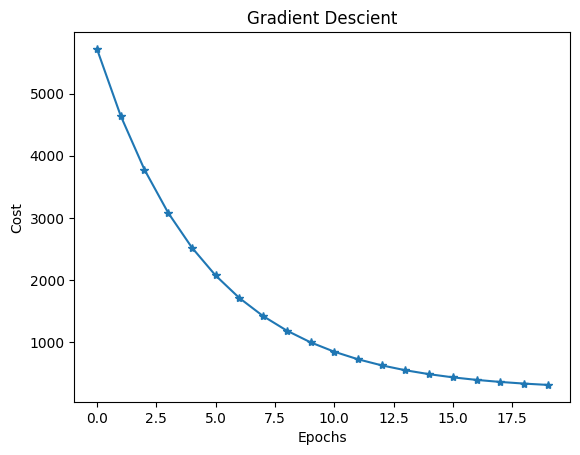

In [27]:
cost, w = fit(X,y)

plt.plot(np.arange(len(cost)), cost, marker='*')
plt.title('Gradient Descient')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()

## Method 2: Stochastic Gradient Descient - Individual Sample

In [21]:
# Step 1: initalize hyperparameters
eta = 0.001
n_iter = 40
random_state = 1

# Step 2: initalize weights (to small random numbers)
rgen = np.random.RandomState(random_state)
w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])

# Step 3: initialize cost lists
cost_ = []


# Step 4: compute net input, linear activation function, update weights, track cost
def fit(X, y):
    for iter_ in range(n_iter):
        cost = []
        # shuffle the data after each iteration to avoid repetitive cycles when we optimize the cost function
        shuffle = np.random.permutation(np.arange(X.shape[0]))
        X, y = X[shuffle], y[shuffle]
        
        # process one sample at a time (this is what makes it SGD)
        for idx, (xi, target) in enumerate(zip(X, y)):
            # make prediction for this single sample
            net_input = np.dot(xi, w_[1:]) + w_[0]
            prediction = net_input  # Linear activation
            
            # compute error for this sample
            error = target - prediction
            
            # update weights using this single sample
            w_[1:] += eta * error * xi
            w_[0] += eta * error
            
            # track cost for this sample
            cost.append(error**2 / 2.0)
        
        # average cost for this epoch
        avg_cost = sum(cost) / len(y)
        cost_.append(avg_cost)
    
    return cost_, w_

# Step 5: compute the threshold (linear) function; it's just the net input function in the linear model
def predict(X):
    net_input = np.dot(X, w_[1:]) + w_[0]
    # threshold function
    y_pred = net_input
    
    return y_pred

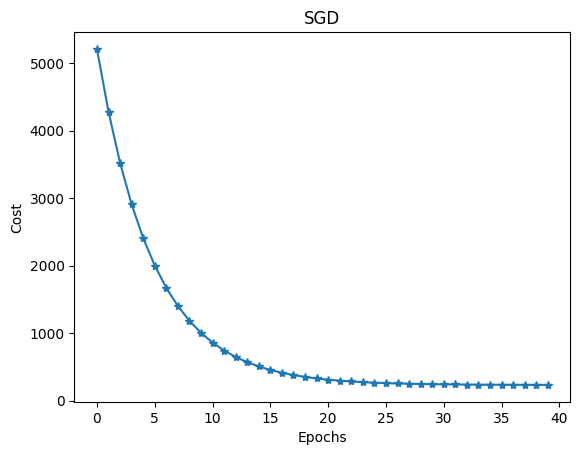

In [22]:
cost, w = fit(X,y)

plt.plot(np.arange(len(cost)), cost, marker='*')
plt.title('SGD')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()

## Method 3: Batch Stochastic Gradient Descient - Multiple Samples

In [23]:
eta = 0.001
iter = 40

def SGD_batch(X, y):
    rgn = np.random.RandomState(seed=42)
    w_ = rgn.normal(loc=0.0, scale=0.1, size = 1 + X.shape[1]) # initialize weights, with bias
    batch_size = 10 # batch size
    batches = np.ceil(X.shape[0] / batch_size).astype('int32')

    m = X.shape[0] # total samples
    cost_ = []


    for _ in range(iter):
        shuffle = np.random.permutation(np.arange(len(X)))
        X, y = X[shuffle], y[shuffle]
        batch_cost = []
        
        for i in range(batches):
            # batch of the samples
            X_batch = X[i*batch_size:(i+1)*batch_size]
            y_batch = y[i*batch_size:(i+1)*batch_size]

            preds = np.dot(X_batch, w_[1:]) + w_[0]
            diff = y_batch - preds
            grad = np.dot(X_batch.T, diff)
            w_[1:] += eta * grad
            w_[0] += eta * diff.sum()

            batch_cost.append((diff ** 2).sum()) # cost per batch
        iter_cost = np.sum(batch_cost) / m # cost per iteration
        cost_.append(iter_cost) # cost all iteration

    return cost_, w_

In [24]:
cost, w = SGD_batch(X,y)

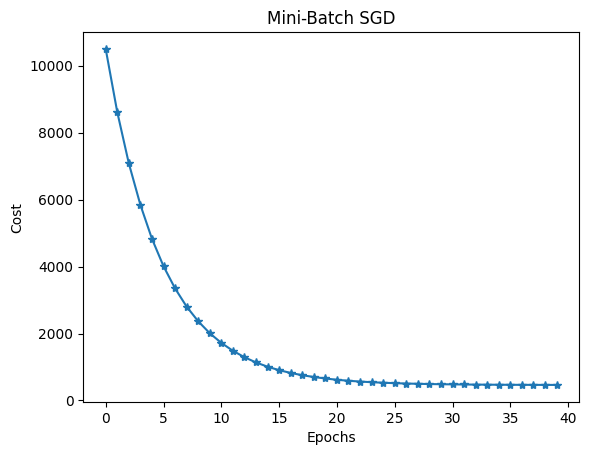

In [25]:
plt.plot(np.arange(len(cost)), cost, marker='*')
plt.title('Mini-Batch SGD')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.show()